# Load Street Parade Embeddings for Analysis

This notebook loads song/track embeddings, artist-level aggregate embeddings, and their metadata from the local Street Parade embeddings database.

Outputs are designed for downstream analysis such as clustering, nearest-neighbor search, UMAP/t-SNE/PCA, or custom metadata filtering.

## What This Loads

- `track_embeddings`: a NumPy matrix with one row per loaded song/track embedding.
- `track_metadata`: a pandas DataFrame aligned row-for-row with `track_embeddings`.
- `artist_embeddings`: a NumPy matrix with one row per artist, computed as the mean of that artist's loaded track embeddings.
- `artist_metadata`: a pandas DataFrame aligned row-for-row with `artist_embeddings`.

The current pipeline stores vectors in ChromaDB. This notebook loads embeddings directly from ChromaDB metadata and uses SQLite only to enrich artist metadata when available. It can fall back to the older legacy `tracks.embedding` BLOB column only if ChromaDB is empty.

In [1]:
from __future__ import annotations

import json
import os
import sqlite3
import sys
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd


In [2]:
# Resolve project paths. If you run this notebook from a different working directory,
# set PROJECT_ROOT manually to the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DB_PATH = Path(os.environ.get("STREETPARADE_DB", PROJECT_ROOT / "data" / "streetparade_embeddings.sqlite3"))
if not DB_PATH.exists():
    DB_PATH = Path(os.environ.get("STREETPARADE_DB", PROJECT_ROOT / "streetparade_embeddings.sqlite3"))

CHROMA_DIR = Path(os.environ.get("STREETPARADE_CHROMA_DIR", PROJECT_ROOT / "chroma"))

DB_PATH, CHROMA_DIR


(PosixPath('/home/charilaos/Workspace/streetparade25_embedings/data/streetparade_embeddings.sqlite3'),
 PosixPath('/home/charilaos/Workspace/streetparade25_embedings/chroma'))

## Loader Helpers

In [3]:
def parse_json(value: Any, default: Any) -> Any:
    if value in (None, ""):
        return default
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError):
        return default


def connect_db(db_path: Path) -> sqlite3.Connection:
    if not db_path.exists():
        raise FileNotFoundError(f"SQLite database not found: {db_path}")
    # immutable=1 avoids WAL housekeeping writes, useful when analyzing a DB
    # snapshot that is not writable by the current user.
    uri = f"file:{db_path.resolve()}?mode=ro&immutable=1"
    conn = sqlite3.connect(uri, uri=True)
    conn.row_factory = sqlite3.Row
    return conn


def rows_to_dataframe(rows: list[sqlite3.Row] | list[dict[str, Any]]) -> pd.DataFrame:
    return pd.DataFrame([dict(row) for row in rows])


def table_exists(conn: sqlite3.Connection, table_name: str) -> bool:
    row = conn.execute("SELECT 1 FROM sqlite_master WHERE type = 'table' AND name = ?", (table_name,)).fetchone()
    return row is not None


def table_columns(conn: sqlite3.Connection, table_name: str) -> set[str]:
    return {row[1] for row in conn.execute(f"PRAGMA table_info({table_name})").fetchall()}


def decode_json_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = df.copy()
    for column in columns:
        if column in df.columns:
            df[column] = df[column].map(lambda value: parse_json(value, [] if column in {"links", "images", "info", "socials"} else {}))
    return df


def embedding_from_blob(blob: bytes | None) -> np.ndarray | None:
    if blob is None:
        return None
    return np.frombuffer(blob, dtype=np.float32)


In [4]:
def load_chroma_embeddings(vector_ids: list[str], chroma_dir: Path) -> dict[str, np.ndarray]:
    """Return vectors from ChromaDB keyed by vector_id."""
    if not vector_ids:
        return {}
    if not chroma_dir.exists():
        print(f"Chroma directory not found: {chroma_dir}")
        return {}

    import chromadb
    from streetparade_embeddings.vectorstore import DEFAULT_COLLECTION

    client = chromadb.PersistentClient(path=str(chroma_dir))
    collection = client.get_or_create_collection(name=DEFAULT_COLLECTION, metadata={"hnsw:space": "cosine"})

    vectors: dict[str, np.ndarray] = {}
    batch_size = 500
    for start in range(0, len(vector_ids), batch_size):
        batch_ids = vector_ids[start:start + batch_size]
        result = collection.get(ids=batch_ids, include=["embeddings"])
        ids = result.get("ids") or []
        embeddings = result.get("embeddings")
        if embeddings is None:
            continue
        for vector_id, embedding in zip(ids, embeddings):
            vectors[str(vector_id)] = np.asarray(embedding, dtype=np.float32)
    return vectors


In [5]:
def load_artist_metadata(db_path: Path) -> pd.DataFrame:
    with connect_db(db_path) as conn:
        artist_columns = table_columns(conn, "artists")
        artist_uuid_sql = "uuid AS artist_uuid" if "uuid" in artist_columns else "NULL AS artist_uuid"
        query = f"""
            SELECT
                id AS artist_id,
                {artist_uuid_sql},
                name AS artist_name,
                links,
                images,
                info,
                socials,
                bio,
                soundcloud_url,
                instagram,
                youtube,
                web
            FROM artists
        """
        df = pd.read_sql_query(query, conn)
    return decode_json_columns(df, ["links", "images", "info", "socials"])


def load_chroma_collection_embeddings(
    chroma_dir: Path,
    *,
    embedding_backend: str | None = None,
    embedding_model: str | None = None,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Load every vector present in the Chroma collection using Chroma metadata."""
    if not chroma_dir.exists():
        return np.empty((0, 0), dtype=np.float32), pd.DataFrame()

    import chromadb
    from streetparade_embeddings.vectorstore import DEFAULT_COLLECTION

    client = chromadb.PersistentClient(path=str(chroma_dir))
    collection = client.get_or_create_collection(name=DEFAULT_COLLECTION, metadata={"hnsw:space": "cosine"})
    count = collection.count()
    if count == 0:
        return np.empty((0, 0), dtype=np.float32), pd.DataFrame()

    ids: list[str] = []
    vectors: list[np.ndarray] = []
    rows: list[dict[str, Any]] = []
    batch_size = 500
    for offset in range(0, count, batch_size):
        result = collection.get(limit=batch_size, offset=offset, include=["embeddings", "metadatas"])
        batch_ids = result.get("ids") or []
        embeddings = result.get("embeddings")
        metadatas = result.get("metadatas") or []
        if embeddings is None:
            continue
        for vector_id, embedding, metadata in zip(batch_ids, embeddings, metadatas):
            metadata = dict(metadata or {})
            if embedding_backend is not None and metadata.get("embedding_backend") != embedding_backend:
                continue
            if embedding_model is not None and metadata.get("embedding_model") != embedding_model:
                continue
            ids.append(str(vector_id))
            vectors.append(np.asarray(embedding, dtype=np.float32))
            rows.append(
                {
                    "vector_id": str(vector_id),
                    "track_id": metadata.get("track_id"),
                    "track_uuid": metadata.get("track_uuid"),
                    "track_url": metadata.get("source_url"),
                    "artist_id": metadata.get("artist_id"),
                    "artist_uuid": metadata.get("artist_uuid"),
                    "embedding_backend": metadata.get("embedding_backend"),
                    "embedding_model": metadata.get("embedding_model"),
                    "embedding_model_config_hash": metadata.get("embedding_model_config_hash"),
                    "sampling_strategy_hash": metadata.get("sampling_strategy_hash"),
                    "embedding_dim": metadata.get("embedding_dim"),
                    "embedded_at": metadata.get("embedded_at"),
                    "embedding_source": "chroma_metadata",
                }
            )

    if not vectors:
        return np.empty((0, 0), dtype=np.float32), pd.DataFrame()
    metadata = pd.DataFrame(rows)
    return np.vstack(vectors).astype(np.float32), metadata


In [6]:
def load_track_embedding_rows(
    db_path: Path,
    *,
    latest_only: bool = True,
    embedding_backend: str | None = None,
    embedding_model: str | None = None,
) -> pd.DataFrame:
    with connect_db(db_path) as conn:
        if not table_exists(conn, "track_embeddings"):
            return pd.DataFrame()

    where = []
    params: list[Any] = []

    if embedding_backend is not None:
        where.append("te.embedding_backend = ?")
        params.append(embedding_backend)
    if embedding_model is not None:
        where.append("te.embedding_model = ?")
        params.append(embedding_model)
    if latest_only:
        where.append(
            """
            te.id = (
                SELECT latest.id
                FROM track_embeddings latest
                WHERE latest.track_id = te.track_id
                ORDER BY latest.embedded_at DESC, latest.id DESC
                LIMIT 1
            )
            """
        )

    where_sql = "WHERE " + " AND ".join(where) if where else ""
    query = f"""
        SELECT
            te.id AS embedding_id,
            te.uuid AS embedding_uuid,
            te.vector_id,
            te.track_id,
            te.artist_id,
            te.artist_uuid,
            te.embedding_backend,
            te.embedding_model,
            te.embedding_model_config,
            te.embedding_model_config_hash,
            te.sampling_strategy,
            te.sampling_strategy_hash,
            te.pipeline_config,
            te.embedding_dim,
            te.embedded_at,
            t.uuid AS track_uuid,
            t.url AS track_url,
            t.path AS track_path,
            t.downloaded,
            t.download_status,
            t.sample_count,
            t.sampling_rate,
            t.chunk_seconds,
            t.chunk_stride_seconds,
            t.max_chunks,
            a.name AS artist_name,
            a.links,
            a.images,
            a.info,
            a.socials,
            a.bio,
            a.soundcloud_url,
            a.instagram,
            a.youtube,
            a.web
        FROM track_embeddings te
        JOIN tracks t ON t.id = te.track_id
        JOIN artists a ON a.id = te.artist_id
        {where_sql}
        ORDER BY a.name, te.track_id, te.embedded_at DESC, te.id DESC
    """

    with connect_db(db_path) as conn:
        df = pd.read_sql_query(query, conn, params=params)
    return decode_json_columns(df, ["links", "images", "info", "socials", "embedding_model_config", "sampling_strategy", "pipeline_config"])


In [7]:
def load_legacy_track_embeddings(db_path: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """Load embeddings stored in the old tracks.embedding BLOB column, if any."""
    with connect_db(db_path) as conn:
        track_columns = table_columns(conn, "tracks")
        artist_columns = table_columns(conn, "artists")

    track_uuid_sql = "t.uuid AS track_uuid" if "uuid" in track_columns else "NULL AS track_uuid"
    artist_uuid_sql = "a.uuid AS artist_uuid" if "uuid" in artist_columns else "NULL AS artist_uuid"

    query = f"""
        SELECT
            t.id AS track_id,
            {track_uuid_sql},
            t.artist_id,
            t.url AS track_url,
            t.path AS track_path,
            t.downloaded,
            t.download_status,
            t.sample_count,
            t.sampling_rate,
            t.chunk_seconds,
            t.chunk_stride_seconds,
            t.max_chunks,
            t.embedding AS embedding_blob,
            t.embedding_dim,
            t.embedding_model,
            t.embedded_at,
            {artist_uuid_sql},
            a.name AS artist_name,
            a.links,
            a.images,
            a.info,
            a.socials,
            a.bio,
            a.soundcloud_url,
            a.instagram,
            a.youtube,
            a.web
        FROM tracks t
        JOIN artists a ON a.id = t.artist_id
        WHERE t.embedding IS NOT NULL
        ORDER BY a.name, t.id
    """
    with connect_db(db_path) as conn:
        df = pd.read_sql_query(query, conn)
    if df.empty:
        return np.empty((0, 0), dtype=np.float32), df.drop(columns=["embedding_blob"], errors="ignore")

    vectors = [embedding_from_blob(blob) for blob in df.pop("embedding_blob")]
    valid = [vector is not None for vector in vectors]
    df = df.loc[valid].reset_index(drop=True)
    if df.empty:
        return np.empty((0, 0), dtype=np.float32), df
    return np.vstack([vector for vector in vectors if vector is not None]).astype(np.float32), decode_json_columns(df, ["links", "images", "info", "socials"])


In [8]:
def load_track_embeddings(
    db_path: Path = DB_PATH,
    chroma_dir: Path = CHROMA_DIR,
    *,
    latest_only: bool = True,
    embedding_backend: str | None = None,
    embedding_model: str | None = None,
    include_legacy_if_chroma_empty: bool = True,
) -> tuple[np.ndarray, pd.DataFrame]:
    embeddings, metadata = load_chroma_collection_embeddings(
        chroma_dir,
        embedding_backend=embedding_backend,
        embedding_model=embedding_model,
    )

    if embeddings.size and not metadata.empty:
        metadata = metadata.copy()
        metadata["_embedding_row"] = np.arange(len(metadata))

        if latest_only and "track_id" in metadata.columns:
            ordered = metadata.sort_values(["track_id", "embedded_at", "vector_id"], na_position="first")
            keep_rows = ordered.drop_duplicates("track_id", keep="last")["_embedding_row"].to_numpy()
            embeddings = embeddings[keep_rows]
            metadata = metadata.iloc[keep_rows].reset_index(drop=True)

        try:
            artists = load_artist_metadata(db_path)
        except Exception as exc:
            print(f"Could not load artist metadata from SQLite: {exc}")
            artists = pd.DataFrame()

        if not artists.empty and "artist_id" in metadata.columns:
            metadata = metadata.merge(artists, on="artist_id", how="left", suffixes=("", "_sqlite"))
            if "artist_uuid_sqlite" in metadata.columns:
                metadata["artist_uuid"] = metadata["artist_uuid"].fillna(metadata["artist_uuid_sqlite"])
                metadata = metadata.drop(columns=["artist_uuid_sqlite"])

        metadata = metadata.drop(columns=["_embedding_row"], errors="ignore")
        return embeddings.astype(np.float32), metadata

    if include_legacy_if_chroma_empty:
        legacy_matrix, legacy_metadata = load_legacy_track_embeddings(db_path)
        if legacy_matrix.size:
            legacy_metadata = legacy_metadata.copy()
            legacy_metadata["embedding_source"] = "legacy_blob"
            return legacy_matrix.astype(np.float32), legacy_metadata

    return np.empty((0, 0), dtype=np.float32), pd.DataFrame()


In [9]:
def aggregate_artist_embeddings(
    track_embeddings: np.ndarray,
    track_metadata: pd.DataFrame,
) -> tuple[np.ndarray, pd.DataFrame]:
    if track_embeddings.size == 0 or track_metadata.empty:
        return np.empty((0, 0), dtype=np.float32), pd.DataFrame()

    artist_rows = []
    artist_vectors = []
    for artist_id, group in track_metadata.groupby("artist_id", sort=True):
        idx = group.index.to_numpy()
        artist_vectors.append(track_embeddings[idx].mean(axis=0))
        first = group.iloc[0]
        artist_rows.append(
            {
                "artist_id": artist_id,
                "artist_uuid": first.get("artist_uuid"),
                "artist_name": first.get("artist_name"),
                "track_embedding_count": len(group),
                "links": first.get("links"),
                "images": first.get("images"),
                "info": first.get("info"),
                "socials": first.get("socials"),
                "bio": first.get("bio"),
                "soundcloud_url": first.get("soundcloud_url"),
                "instagram": first.get("instagram"),
                "youtube": first.get("youtube"),
                "web": first.get("web"),
            }
        )

    return np.vstack(artist_vectors).astype(np.float32), pd.DataFrame(artist_rows)


## Load Data

In [10]:
track_embeddings, track_metadata = load_track_embeddings(
    DB_PATH,
    CHROMA_DIR,
    latest_only=True,
    embedding_backend=None,  # e.g. "clap"
    embedding_model=None,    # e.g. "laion/clap-htsat-unfused"
    include_legacy_if_chroma_empty=True,
)

artist_embeddings, artist_metadata = aggregate_artist_embeddings(track_embeddings, track_metadata)

print(f"Track embeddings:  {track_embeddings.shape}")
print(f"Track metadata:    {track_metadata.shape}")
print(f"Artist embeddings: {artist_embeddings.shape}")
print(f"Artist metadata:   {artist_metadata.shape}")


Track embeddings:  (380, 512)
Track metadata:    (380, 23)
Artist embeddings: (96, 512)
Artist metadata:   (96, 13)


In [11]:
track_metadata.head()

,vector_id,track_id,track_uuid,track_url,artist_id,artist_uuid,embedding_backend,embedding_model,embedding_model_config_hash,sampling_strategy_hash,...,artist_name,links,images,info,socials,bio,soundcloud_url,instagram,youtube,web
0,track:9:embedding:96ee3e854d9c40eba76d21e104b3...,9,0c9106011e4b49e18b5a6240bd6725cc,https://soundcloud.com/aiiamusic/live-ibiza-so...,4,854c2dc5ce454c31893048bfe2a7ddc0,clap,laion/clap-htsat-unfused,20f77ad1bc1aabe034978b696070956214927544b72dbe...,612b8ac43d5cafbb6840ac97041a7ec449f06973676961...,...,Agent C,"[https://www.instagram.com/cerni_agent_c, http...",[https://www.streetparade.com/media/pages/line...,[JUR Records (AG)],"[{'platform': 'instagram', 'url': 'https://www...",Cerni aka Agent C kam durch seinen Freund Rena...,NaN,https://www.instagram.com/cerni_agent_c,NaN,https://www.jurrecords.ch
1,track:10:embedding:a1680625d3b04b61b7aaf519127...,10,e9795ccc255b4a82a260c2cef2e3baf9,https://soundcloud.com/aiiamusic/au-revoir-ope...,4,854c2dc5ce454c31893048bfe2a7ddc0,clap,laion/clap-htsat-unfused,20f77ad1bc1aabe034978b696070956214927544b72dbe...,612b8ac43d5cafbb6840ac97041a7ec449f06973676961...,...,Agent C,"[https://www.instagram.com/cerni_agent_c, http...",[https://www.streetparade.com/media/pages/line...,[JUR Records (AG)],"[{'platform': 'instagram', 'url': 'https://www...",Cerni aka Agent C kam durch seinen Freund Rena...,NaN,https://www.instagram.com/cerni_agent_c,NaN,https://www.jurrecords.ch
2,track:11:embedding:f6c0c82b20cb412189507414302...,11,1b171b8ca3a84da5a6372de5793fedf0,https://soundcloud.com/aiiamusic/hive-air-spec...,4,854c2dc5ce454c31893048bfe2a7ddc0,clap,laion/clap-htsat-unfused,20f77ad1bc1aabe034978b696070956214927544b72dbe...,612b8ac43d5cafbb6840ac97041a7ec449f06973676961...,...,Agent C,"[https://www.instagram.com/cerni_agent_c, http...",[https://www.streetparade.com/media/pages/line...,[JUR Records (AG)],"[{'platform': 'instagram', 'url': 'https://www...",Cerni aka Agent C kam durch seinen Freund Rena...,NaN,https://www.instagram.com/cerni_agent_c,NaN,https://www.jurrecords.ch
3,track:12:embedding:06bea86472084acbaa8e7b73d38...,12,ad7b9c5b1e3b4de1becc2db6960e82b6,https://soundcloud.com/aiiamusic/dihive-hive-c...,4,854c2dc5ce454c31893048bfe2a7ddc0,clap,laion/clap-htsat-unfused,20f77ad1bc1aabe034978b696070956214927544b72dbe...,612b8ac43d5cafbb6840ac97041a7ec449f06973676961...,...,Agent C,"[https://www.instagram.com/cerni_agent_c, http...",[https://www.streetparade.com/media/pages/line...,[JUR Records (AG)],"[{'platform': 'instagram', 'url': 'https://www...",Cerni aka Agent C kam durch seinen Freund Rena...,NaN,https://www.instagram.com/cerni_agent_c,NaN,https://www.jurrecords.ch
4,track:18:embedding:4c98279a784f4ef1ad32df82f75...,18,bbfc6fe49f2c4e719b370bac7bb0ee9c,https://soundcloud.com/djaleno/unreleased-seri...,6,aabfa4053e4e4f7696fc64a513fd5865,clap,laion/clap-htsat-unfused,20f77ad1bc1aabe034978b696070956214927544b72dbe...,612b8ac43d5cafbb6840ac97041a7ec449f06973676961...,...,AIIA • Hive Club (ZH),"[https://www.instagram.com/aiia.music_/, https...",[https://www.streetparade.com/media/pages/line...,[18:00 Clubbing Stage],"[{'platform': 'instagram', 'url': 'https://www...",AllA is an electronic DJ duo based in Zurich. ...,https://soundcloud.com/aiiamusic,https://www.instagram.com/aiia.music_/,https://www.youtube.com/channel/UCGaPKtvHdU-4v...,NaN


In [12]:
artist_metadata.head()

,artist_id,artist_uuid,artist_name,track_embedding_count,links,images,info,socials,bio,soundcloud_url,instagram,youtube,web
0,4,854c2dc5ce454c31893048bfe2a7ddc0,Agent C,4,"[https://www.instagram.com/cerni_agent_c, http...",[https://www.streetparade.com/media/pages/line...,[JUR Records (AG)],"[{'platform': 'instagram', 'url': 'https://www...",Cerni aka Agent C kam durch seinen Freund Rena...,NaN,https://www.instagram.com/cerni_agent_c,NaN,https://www.jurrecords.ch
1,6,aabfa4053e4e4f7696fc64a513fd5865,AIIA • Hive Club (ZH),5,"[https://www.instagram.com/aiia.music_/, https...",[https://www.streetparade.com/media/pages/line...,[18:00 Clubbing Stage],"[{'platform': 'instagram', 'url': 'https://www...",AllA is an electronic DJ duo based in Zurich. ...,https://soundcloud.com/aiiamusic,https://www.instagram.com/aiia.music_/,https://www.youtube.com/channel/UCGaPKtvHdU-4v...,NaN
2,7,3b0f8dbe7feb4d0fb3fe3565fd6043f4,Alanor,5,"[https://www.instagram.com/djalanor, https://s...",[https://www.streetparade.com/media/pages/line...,[Magic MaRoNi x Labil mit Stil (TG/ZH)],"[{'platform': 'instagram', 'url': 'https://www...","Alanor ist ein aufstrebender DJ aus Zürich, be...",https://soundcloud.com/djalanor,https://www.instagram.com/djalanor,NaN,https://labilmitstil.ch
3,9,ce893307ce8045209e79a92ee9774d4f,Alessio Sassano,4,[https://www.instagram.com/alessiosassano_offi...,[https://www.streetparade.com/media/pages/line...,[Hard Music Association],"[{'platform': 'instagram', 'url': 'https://www...",Alessio Sassano is an Italian hardcore and upt...,https://soundcloud.com/alesssiosassano,https://www.instagram.com/alessiosassano_offic...,NaN,NaN
4,14,ab646a21b9374d2abeef0bbc596edb60,Andrew Larave,3,"[https://www.instagram.com/andrew.larave, http...",[https://www.streetparade.com/media/pages/line...,[Animalz x G-Town Production (SO)],"[{'platform': 'instagram', 'url': 'https://www...",Andrew Larave ist ein Schweizer Trance-DJ der ...,NaN,https://www.instagram.com/andrew.larave,NaN,NaN


## Optional: Save Analysis-Ready Arrays

This writes compact local files that can be loaded without touching SQLite/Chroma again.

In [13]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "analysis_embeddings"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUTPUT_DIR / "track_embeddings.npy", track_embeddings)
np.save(OUTPUT_DIR / "artist_embeddings.npy", artist_embeddings)
track_metadata.to_json(OUTPUT_DIR / "track_metadata.jsonl", orient="records", lines=True, force_ascii=False)
artist_metadata.to_json(OUTPUT_DIR / "artist_metadata.jsonl", orient="records", lines=True, force_ascii=False)

OUTPUT_DIR


PosixPath('/home/charilaos/Workspace/streetparade25_embedings/outputs/analysis_embeddings')

## Optional: PCA Preview

Install `scikit-learn` if this cell is useful and not already available in your environment.

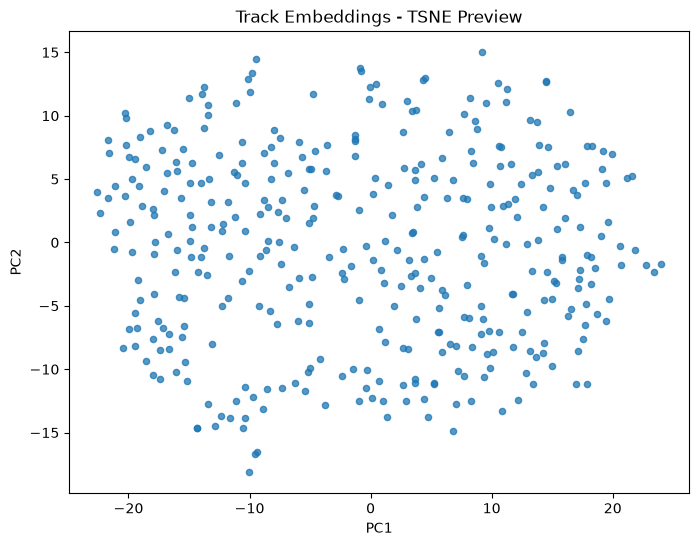

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

if track_embeddings.shape[0] >= 2:
    coords = TSNE(n_components=2).fit_transform(track_embeddings)
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.75)
    plt.title("Track Embeddings - TSNE Preview")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
